In [1]:
# CELL 1: Generate Synthetic Biogas Data
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

print("Generating synthetic biogas production data...")

# Set random seed for reproducibility
np.random.seed(42)

# Create date range: 1 year of daily data
dates = pd.date_range(start='2023-01-01', periods=365, freq='D')

# Generate realistic biogas production patterns
base_production = 500  # m³/day
seasonal = 100 * np.sin(np.arange(365) * 2 * np.pi / 365)  # seasonal cycle
noise = np.random.normal(0, 30, 365)  # random variation
biogas_yield = base_production + seasonal + noise

# Generate operational parameters
temperature = 37 + 2 * np.sin(np.arange(365) * 2 * np.pi / 365) + np.random.normal(0, 1, 365)
pH = 7.0 + np.random.normal(0, 0.3, 365)
organic_loading = 3.5 + 0.5 * np.sin(np.arange(365) * 2 * np.pi / 180) + np.random.normal(0, 0.2, 365)

# Create DataFrame
df = pd.DataFrame({
    'date': dates,
    'biogas_yield_m3': np.maximum(biogas_yield, 0),  # no negative production
    'temperature_C': temperature,
    'pH': pH,
    'organic_loading_kgVS_m3d': organic_loading
})

# Save to CSV
df.to_csv('../data/raw/biogas_synthetic.csv', index=False)

print("Data generated successfully!")
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\n First 5 rows:")
print(df.head())
print("\n Basic statistics:")
print(df.describe())

Generating synthetic biogas production data...
Data generated successfully!
Dataset shape: 365 rows, 5 columns

 First 5 rows:
        date  biogas_yield_m3  temperature_C        pH  \
0 2023-01-01       514.901425      36.598780  7.058754   
1 2023-01-02       497.573407      37.258519  6.706488   
2 2023-01-03       522.872817      37.081436  7.122476   
3 2023-01-04       550.852862      37.200915  6.489225   
4 2023-01-05       499.855641      36.364595  7.308747   

   organic_loading_kgVS_m3d  
0                  3.483857  
1                  3.533177  
2                  3.135238  
3                  3.735530  
4                  3.638884  

 Basic statistics:
                      date  biogas_yield_m3  temperature_C          pH  \
count                  365       365.000000     365.000000  365.000000   
mean   2023-07-02 00:00:00       500.298392      36.961986    7.038081   
min    2023-01-01 00:00:00       304.800611      32.318669    6.145437   
25%    2023-04-02 00:00:00  

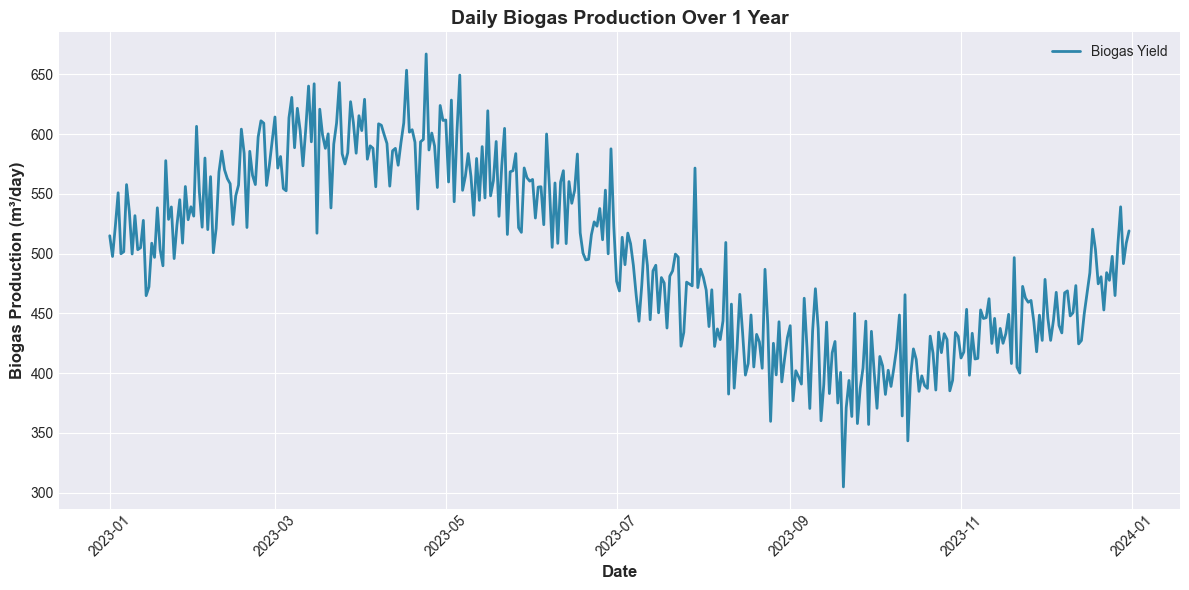

Visualization created successfully!
Plot saved to: results/figures/biogas_time_series.png


In [2]:
# CELL 2: Visualize Biogas Production Over Time
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')

# Create figure with specific size
plt.figure(figsize=(12, 6))

# Plot biogas yield over time
plt.plot(df['date'], df['biogas_yield_m3'], 
         color='#2E86AB', linewidth=2, label='Biogas Yield')

# Add labels and title
plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.ylabel('Biogas Production (m³/day)', fontsize=12, fontweight='bold')
plt.title('Daily Biogas Production Over 1 Year', fontsize=14, fontweight='bold')
plt.legend(loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()

# Save the figure
plt.savefig('../results/figures/biogas_time_series.png', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

print("Visualization created successfully!")
print("Plot saved to: results/figures/biogas_time_series.png")

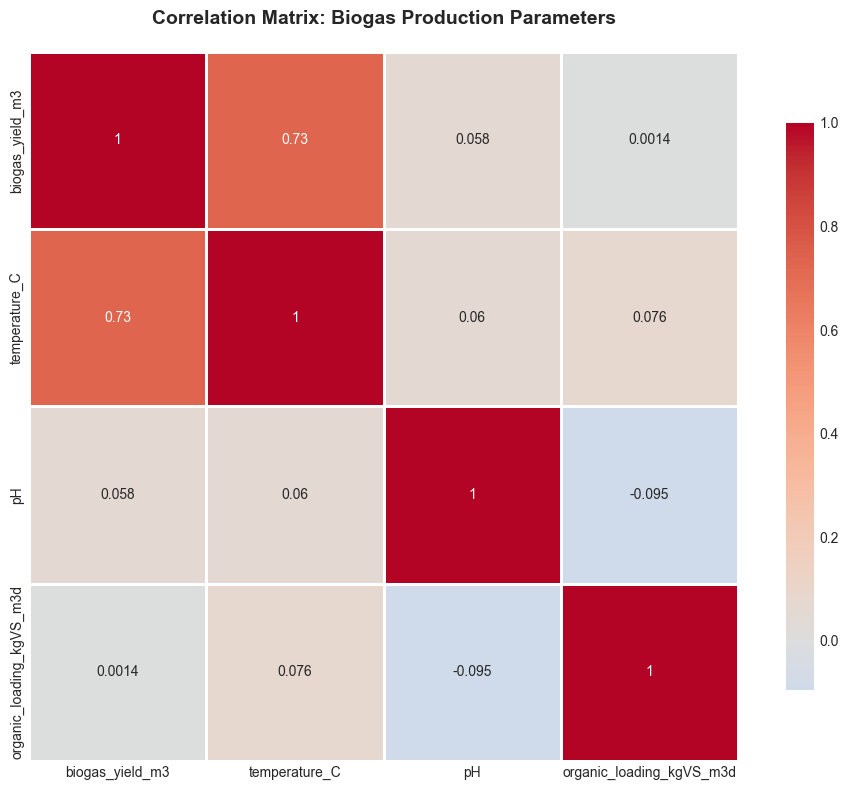

 Correlation heatmap created!

 Key Insights:
   - Temperature vs Biogas Yield: 0.733
   - pH vs Biogas Yield: 0.058
   - Organic Loading vs Biogas Yield: 0.001


In [3]:
# CELL 3: Correlation Analysis
import matplotlib.pyplot as plt
import seaborn as sns

# Create correlation matrix
correlation_matrix = df[['biogas_yield_m3', 'temperature_C', 'pH', 'organic_loading_kgVS_m3d']].corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Create heatmap
sns.heatmap(correlation_matrix, 
            annot=True,      # Show numbers in cells
            cmap='coolwarm', # Color scheme
            center=0,        # Center colormap at 0
            square=True,     # Make cells square
            linewidths=1,    # Lines between cells
            cbar_kws={"shrink": 0.8})

plt.title('Correlation Matrix: Biogas Production Parameters', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()

# Save the figure
plt.savefig('../results/figures/correlation_heatmap.png', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

print(" Correlation heatmap created!")
print("\n Key Insights:")
print(f"   - Temperature vs Biogas Yield: {correlation_matrix.loc['temperature_C', 'biogas_yield_m3']:.3f}")
print(f"   - pH vs Biogas Yield: {correlation_matrix.loc['pH', 'biogas_yield_m3']:.3f}")
print(f"   - Organic Loading vs Biogas Yield: {correlation_matrix.loc['organic_loading_kgVS_m3d', 'biogas_yield_m3']:.3f}")

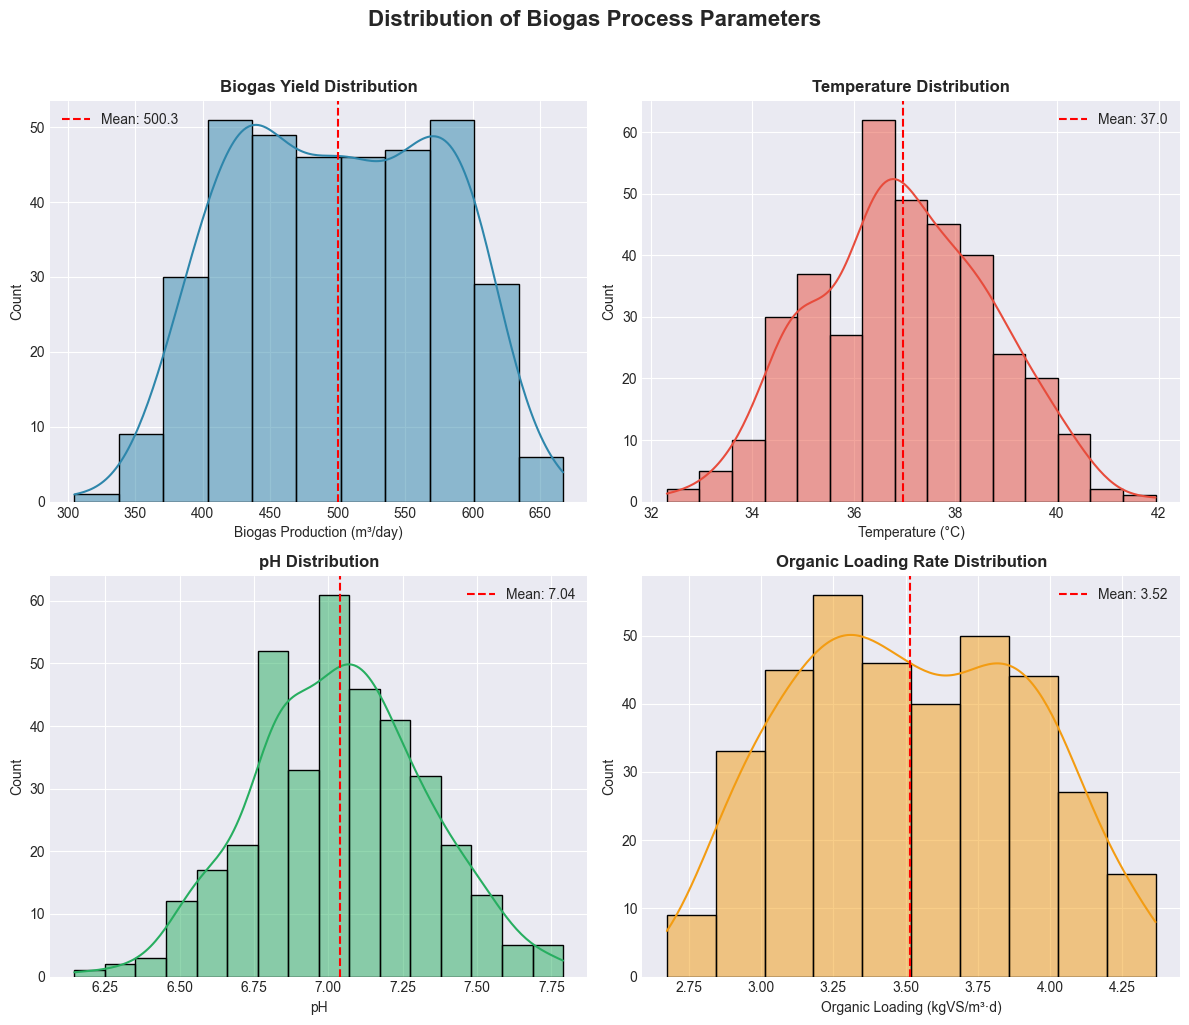

Distribution plots created successfully!
Saved to: results/figures/distribution_plots.png


In [4]:
# CELL 4: Distribution Analysis of Variables
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure with subplots (2x2 grid)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Biogas Yield Distribution
sns.histplot(df['biogas_yield_m3'], kde=True, ax=axes[0, 0], color='#2E86AB')
axes[0, 0].set_title('Biogas Yield Distribution', fontweight='bold')
axes[0, 0].set_xlabel('Biogas Production (m³/day)')
axes[0, 0].axvline(df['biogas_yield_m3'].mean(), color='red', linestyle='--', 
                   label=f"Mean: {df['biogas_yield_m3'].mean():.1f}")
axes[0, 0].legend()

# Plot 2: Temperature Distribution
sns.histplot(df['temperature_C'], kde=True, ax=axes[0, 1], color='#E74C3C')
axes[0, 1].set_title('Temperature Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Temperature (°C)')
axes[0, 1].axvline(df['temperature_C'].mean(), color='red', linestyle='--',
                   label=f"Mean: {df['temperature_C'].mean():.1f}")
axes[0, 1].legend()

# Plot 3: pH Distribution
sns.histplot(df['pH'], kde=True, ax=axes[1, 0], color='#27AE60')
axes[1, 0].set_title('pH Distribution', fontweight='bold')
axes[1, 0].set_xlabel('pH')
axes[1, 0].axvline(df['pH'].mean(), color='red', linestyle='--',
                   label=f"Mean: {df['pH'].mean():.2f}")
axes[1, 0].legend()

# Plot 4: Organic Loading Rate Distribution
sns.histplot(df['organic_loading_kgVS_m3d'], kde=True, ax=axes[1, 1], color='#F39C12')
axes[1, 1].set_title('Organic Loading Rate Distribution', fontweight='bold')
axes[1, 1].set_xlabel('Organic Loading (kgVS/m³·d)')
axes[1, 1].axvline(df['organic_loading_kgVS_m3d'].mean(), color='red', linestyle='--',
                   label=f"Mean: {df['organic_loading_kgVS_m3d'].mean():.2f}")
axes[1, 1].legend()

plt.suptitle('Distribution of Biogas Process Parameters', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# Save the figure
plt.savefig('../results/figures/distribution_plots.png', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

print("Distribution plots created successfully!")
print("Saved to: results/figures/distribution_plots.png")